In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

In [10]:
import numpy as np

class KmeanClustering:

    def __init__(self, k=3):
        self.k = k
        self.centroids = None

    @staticmethod
    def euclidean_distance(data_point, centroids):
        return np.sqrt(np.sum((centroids - data_point) ** 2, axis=1))

    def fit(self, X, max_iterations=200):

        # Initialize centroids
        self.centroids = np.random.uniform(
            np.amin(X, axis=0),
            np.amax(X, axis=0),
            size=(self.k, X.shape[1])
        )

        for _ in range(max_iterations):

            y = []

            # Assign each point to nearest centroid
            for data_point in X:

                distances = KmeanClustering.euclidean_distance(
                    data_point,
                    self.centroids
                )

                cluster_num = np.argmin(distances)
                y.append(cluster_num)

            y = np.array(y)

            # Find points belonging to each cluster
            cluster_indices = []

            for i in range(self.k):
                cluster_indices.append(np.argwhere(y == i))

            # Calculate new centroids
            cluster_centers = []

            for i, indices in enumerate(cluster_indices):

                if len(indices) == 0:
                    cluster_centers.append(self.centroids[i])

                else:
                    cluster_centers.append(
                        np.mean(X[indices.flatten()], axis=0)
                    )

            cluster_centers = np.array(cluster_centers)

            # Check convergence
            if np.max(np.abs(self.centroids - cluster_centers)) < 0.001:
                break

            self.centroids = cluster_centers

        return y

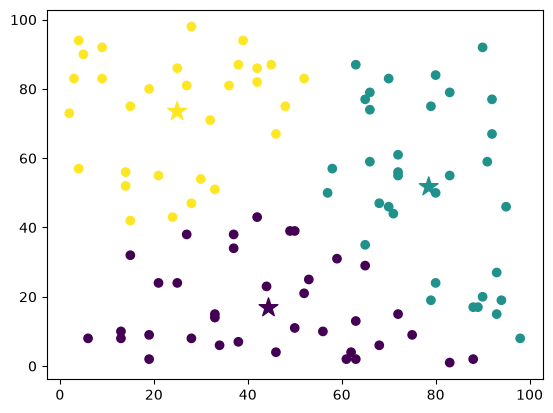

In [16]:
random_points = np.random.randint(0, 100, (100, 2))

kmeans = KmeanClustering(k=3)

labels = kmeans.fit(random_points)

plt.scatter(
    random_points[:, 0],
    random_points[:, 1],
    c=labels
)

plt.scatter(
    kmeans.centroids[:, 0],
    kmeans.centroids[:, 1],
    c=range(len(kmeans.centroids)),
    marker="*",
    s=200
)

plt.show()

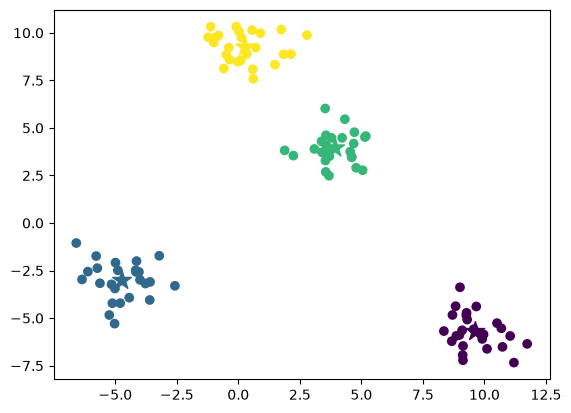

In [24]:
from sklearn.datasets import make_blobs

data= make_blobs(n_samples=100,n_features=2,centers=4)
random_points = data[0]
kmeans = KmeanClustering(k=4)

labels = kmeans.fit(random_points)

plt.scatter(
    random_points[:, 0],
    random_points[:, 1],
    c=labels
)

plt.scatter(
    kmeans.centroids[:, 0],
    kmeans.centroids[:, 1],
    c=range(len(kmeans.centroids)),
    marker="*",
    s=200
)

plt.show()